# 05 · Gate attribution on the qshaptools QAOA benchmark

**Computes.** Gate Shapley values for the \texttt{qshaptools} QAOA example ($H=Z_0Z_1+2Z_0-3Z_2$, a QAOA ansatz decomposed to $m=13$ gate players) via the **channel-mixture multilinear extension** (Owen, $M=\lceil m/2\rceil=7$) versus **SVQX exact** $2^{13}$ enumeration and **SVQX subsampled** Monte-Carlo. Owen reproduces the exact gate Shapley to machine precision using $2m\lceil m/2\rceil=182$ extension evaluations versus $2^{13}=8192$ SVQX value evaluations; the subsampled estimator is inexact at comparable budget.

**Produces.** `figures/fig_gate_first.png` and `results/05.json`.

**Seed.** Fixed: SVQX Monte-Carlo seeds 0..2 averaged.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt
import tnshapq as T
from tnshapq import exact, owen, svqx, metrics
from tnshapq.io_utils import save_results, savefig

np.random.seed(0)
plt.rcParams.update({'font.size': 13, 'axes.titlesize': 13, 'axes.labelsize': 13,
                     'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 11})

In [2]:
# Build the QAOA gate game and the exact (SVQX) reference
qc, H, game = T.build_qaoa_example()
m = game.n
M = T.threshold_M(m, 1)                              # ceil(13/2) = 7
print(f"m = {m} gate players on {qc.num_qubits} qubits; SVQX exact = 2^{m} = {2**m} evaluations")
table = exact.exact_value_table(game)               # 2^13 SVQX value evaluations
phi_exact = exact.exact_shapley(table, m)           # SVQX exact gate Shapley

m = 13 gate players on 3 qubits; SVQX exact = 2^13 = 8192 evaluations


In [3]:
# Channel-mixture Owen gate Shapley (M=7): exact at 182 extension evaluations
phi_owen, n_owen = owen.gate_owen_shapley(game, M)
max_err = metrics.max_abs_err(phi_owen, phi_exact)
print(f"Owen M={M}: {n_owen} extension evaluations, max|err| vs SVQX exact = {max_err:.2e}")
print(f"  ratio 2^m / Owen = {2**m / n_owen:.0f}x fewer evaluations")

Owen M=7: 182 extension evaluations, max|err| vs SVQX exact = 4.05e-15
  ratio 2^m / Owen = 45x fewer evaluations


In [4]:
# SVQX subsampled Monte-Carlo at several budgets (inexact, converges only in the limit)
alphas = [0.05, 0.10, 0.20, 0.40]
seeds = [0, 1, 2]
svqx_pts = []
for a in alphas:
    errs = []
    for s in seeds:
        phi_s = svqx.svqx_mc_shapley(game, alpha=a, rng=np.random.default_rng(s))
        errs.append(metrics.max_abs_err(phi_s, phi_exact))
    ev = svqx.svqx_eval_count(game, a)
    svqx_pts.append((ev, float(np.mean(errs))))
    print(f"SVQX subsampled alpha={a:.2f}: ~{ev} evals, mean max|err|={np.mean(errs):.2e}")

SVQX subsampled alpha=0.05: ~5330 evals, mean max|err|=1.93e-01


SVQX subsampled alpha=0.10: ~10660 evals, mean max|err|=1.12e-01


SVQX subsampled alpha=0.20: ~21320 evals, mean max|err|=1.23e-01


SVQX subsampled alpha=0.40: ~42614 evals, mean max|err|=7.25e-02


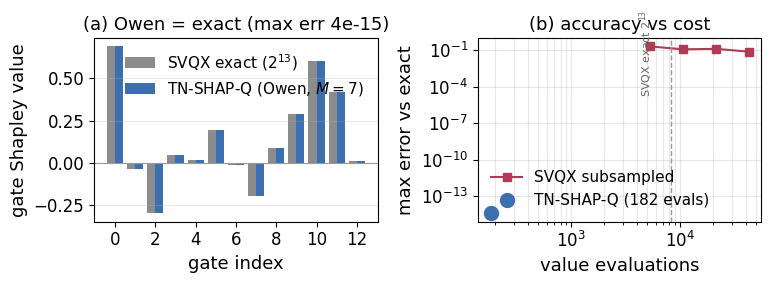

saved figures/fig_gate_first.png


In [5]:
# Figure: (a) per-gate Shapley exact vs Owen; (b) accuracy vs cost
fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.8, 3.0))
xb = np.arange(m); wid = 0.4
a1.bar(xb - wid/2, phi_exact, wid, color='0.55', label=r'SVQX exact ($2^{13}$)')
a1.bar(xb + wid/2, phi_owen, wid, color='#3b6fb0', label=r'TN-SHAP-Q (Owen, $M{=}7$)')
a1.axhline(0, color='0.6', lw=0.8); a1.set_xticks(xb[::2])
a1.set_xlabel('gate index'); a1.set_ylabel('gate Shapley value')
a1.set_title(f'(a) Owen = exact (max err {max_err:.0e})')
a1.legend(frameon=False); a1.grid(alpha=0.3, axis='y')

sv_ev = [p[0] for p in svqx_pts]; sv_er = [p[1] for p in svqx_pts]
a2.loglog(sv_ev, sv_er, 's-', color='#b03b54', label='SVQX subsampled')
a2.loglog([n_owen], [max(max_err, 1e-16)], 'o', color='#3b6fb0', ms=10,
          label=f'TN-SHAP-Q ({n_owen} evals)')
a2.axvline(2**m, color='0.6', ls='--', lw=1)
a2.text(2**m * 0.5, 5e-2, r'SVQX exact $2^{13}$', rotation=90, va='center', fontsize=8, color='0.4')
a2.set_xlabel('value evaluations'); a2.set_ylabel('max error vs exact')
a2.set_title('(b) accuracy vs cost'); a2.legend(frameon=False, loc='lower left')
a2.grid(alpha=0.3, which='both')
fig.tight_layout()
savefig(fig, 'fig_gate_first.png')
plt.show()
print("saved figures/fig_gate_first.png")

In [6]:
res = {
    "task": "gate first-order Shapley (qshaptools QAOA, m=13)",
    "m": m, "M": int(M), "owen_evals": int(n_owen), "enum_evals": int(2**m),
    "speedup": float(2**m / n_owen), "max_err": float(max_err),
    "svqx_subsampled": [{"alpha": a, "evals": int(ev), "max_err": float(er)}
                        for a, (ev, er) in zip(alphas, svqx_pts)],
    "phi_exact": phi_exact.tolist(), "phi_owen": phi_owen.tolist(),
    "threshold_ok": bool(max_err < 1e-12),
}
save_results("05", res)
print("saved results/05.json")

saved results/05.json


In [7]:
# Verification: Owen matches SVQX exact enumeration to machine precision
np.testing.assert_allclose(phi_owen, phi_exact, atol=1e-12, rtol=0)
print(f"PASS  Owen M={M} reproduces SVQX 2^{m}={2**m} enumeration: max err {max_err:.2e}, "
      f"{n_owen} evals ({2**m // n_owen}x fewer).")
print(f"      SVQX subsampled at ~{svqx_pts[-1][0]} evals still off by {svqx_pts[-1][1]:.2e}.")

PASS  Owen M=7 reproduces SVQX 2^13=8192 enumeration: max err 4.05e-15, 182 evals (45x fewer).
      SVQX subsampled at ~42614 evals still off by 7.25e-02.
